In [1]:
import requests
import pandas as pd

# Test the API with a simple request - 2023 race results
url = "https://api.jolpi.ca/ergast/f1/2023/results.json"
response = requests.get(url)

print("Status Code:", response.status_code)
data = response.json()
print(data.keys())

Status Code: 200
dict_keys(['MRData'])


In [2]:
import time

all_results = []

for year in range(2019, 2024):
    for round_num in range(1, 24):  # up to 23 races per season
        url = f"https://api.jolpi.ca/ergast/f1/{year}/{round_num}/results.json"
        response = requests.get(url)
        
        if response.status_code != 200:
            continue
        
        data = response.json()
        races = data['MRData']['RaceTable']['Races']
        
        if not races:
            continue
        
        race = races[0]
        for result in race['Results']:
            all_results.append({
                'season': year,
                'round': round_num,
                'race_name': race['raceName'],
                'circuit': race['Circuit']['circuitName'],
                'date': race['date'],
                'driver': result['Driver']['givenName'] + ' ' + result['Driver']['familyName'],
                'constructor': result['Constructor']['name'],
                'grid': int(result['grid']),
                'position': result.get('position'),
                'points': float(result['points']),
                'status': result['status'],
                'laps': int(result['laps'])
            })
        
        time.sleep(0.3)  # be polite to the free API, avoid rate limiting
    
    print(f"Finished season {year}")

print(f"\nTotal results collected: {len(all_results)}")

Finished season 2019
Finished season 2020
Finished season 2021
Finished season 2022
Finished season 2023

Total results collected: 2080


In [3]:
results_df = pd.DataFrame(all_results)
print(results_df.shape)
results_df.head(10)

(2080, 12)


,season,round,race_name,circuit,date,driver,constructor,grid,position,points,status,laps
0,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Valtteri Bottas,Mercedes,2,1,26.0,Finished,58
1,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Lewis Hamilton,Mercedes,1,2,18.0,Finished,58
2,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Max Verstappen,Red Bull,4,3,15.0,Finished,58
3,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Sebastian Vettel,Ferrari,3,4,12.0,Finished,58
4,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Charles Leclerc,Ferrari,5,5,10.0,Finished,58
5,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Kevin Magnussen,Haas F1 Team,7,6,8.0,Finished,58
6,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Nico Hülkenberg,Renault,11,7,6.0,+1 Lap,57
7,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Kimi Räikkönen,Alfa Romeo,9,8,4.0,+1 Lap,57
8,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Lance Stroll,Racing Point,16,9,2.0,+1 Lap,57
9,2019,1,Australian Grand Prix,Albert Park Grand Prix Circuit,2019-03-17,Daniil Kvyat,Toro Rosso,15,10,1.0,+1 Lap,57


In [4]:
results_df.to_csv('../data/race_results.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [5]:
winners = results_df[results_df['position'] == '1']
top_winners = winners['driver'].value_counts().head(10)
top_winners

driver
Max Verstappen      49
Lewis Hamilton      30
Valtteri Bottas      7
Sergio Pérez         6
Charles Leclerc      5
Carlos Sainz         2
Sebastian Vettel     1
Pierre Gasly         1
Esteban Ocon         1
Daniel Ricciardo     1
Name: count, dtype: int64

In [6]:
lap_data = []

for round_num in range(1, 23):  # 2023 season had 22 races
    url = f"https://api.jolpi.ca/ergast/f1/2023/{round_num}/laps.json?limit=2000"
    response = requests.get(url)
    
    if response.status_code != 200:
        continue
    
    data = response.json()
    races = data['MRData']['RaceTable']['Races']
    
    if not races:
        continue
    
    race = races[0]
    race_name = race['raceName']
    
    for lap in race['Laps']:
        lap_number = lap['number']
        for timing in lap['Timings']:
            lap_data.append({
                'season': 2023,
                'round': round_num,
                'race_name': race_name,
                'lap': int(lap_number),
                'driver_id': timing['driverId'],
                'position': int(timing['position']),
                'time': timing['time']
            })
    
    print(f"Round {round_num}: {race_name} - done")
    time.sleep(0.3)

print(f"\nTotal lap records collected: {len(lap_data)}")

Round 1: Bahrain Grand Prix - done
Round 2: Saudi Arabian Grand Prix - done
Round 3: Australian Grand Prix - done
Round 4: Azerbaijan Grand Prix - done
Round 5: Miami Grand Prix - done
Round 6: Monaco Grand Prix - done
Round 7: Spanish Grand Prix - done
Round 8: Canadian Grand Prix - done
Round 9: Austrian Grand Prix - done
Round 10: British Grand Prix - done
Round 11: Hungarian Grand Prix - done
Round 12: Belgian Grand Prix - done
Round 13: Dutch Grand Prix - done
Round 14: Italian Grand Prix - done
Round 15: Singapore Grand Prix - done
Round 16: Japanese Grand Prix - done
Round 17: Qatar Grand Prix - done
Round 18: United States Grand Prix - done
Round 19: Mexico City Grand Prix - done
Round 20: São Paulo Grand Prix - done
Round 21: Las Vegas Grand Prix - done
Round 22: Abu Dhabi Grand Prix - done

Total lap records collected: 2200


In [7]:
lap_df_check = pd.DataFrame(lap_data)
print(lap_df_check['round'].unique())
print(lap_df_check['round'].value_counts())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
round
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
Name: count, dtype: int64


In [ ]:
lap_data = []  # reset and start fresh

for round_num in range(1, 23):
    offset = 0
    round_total = 0
    
    while True:
        url = f"https://api.jolpi.ca/ergast/f1/2023/{round_num}/laps.json?limit=100&offset={offset}"
        response = requests.get(url)
        
        if response.status_code != 200:
            break
        
        data = response.json()
        races = data['MRData']['RaceTable']['Races']
        total_available = int(data['MRData']['total'])
        
        if not races:
            break
        
        race = races[0]
        race_name = race['raceName']
        
        for lap in race['Laps']:
            lap_number = lap['number']
            for timing in lap['Timings']:
                lap_data.append({
                    'season': 2023,
                    'round': round_num,
                    'race_name': race_name,
                    'lap': int(lap_number),
                    'driver_id': timing['driverId'],
                    'position': int(timing['position']),
                    'time': timing['time']
                })
        
        round_total += len(race['Laps']) * 20  # rough estimate for progress display
        offset += 100
        
        if offset >= total_available:
            break
        
        time.sleep(0.3)
    
    print(f"Round {round_num}: {race_name} - done ({offset} records checked)")

print(f"\nTotal lap records collected: {len(lap_data)}")

In [ ]:
lap_df = pd.DataFrame(lap_data)
print(lap_df.shape)
lap_df.head(10)

In [12]:
lap_df.to_csv('../data/lap_times.csv', index=False)
print("Lap data saved successfully!")

Lap data saved successfully!


In [13]:
abu_dhabi_leaders = lap_df[(lap_df['round'] == 22) & (lap_df['position'] == 1)]
abu_dhabi_leaders[['lap', 'driver_id']].head(20)

,lap,driver_id
16662,1,max_verstappen
16682,2,max_verstappen
16702,3,max_verstappen
16722,4,max_verstappen
16742,5,max_verstappen


In [15]:
def parse_duration(duration_str):
    """Convert pit stop duration to seconds, handling both '25.181' and '1:15.181' formats"""
    if ':' in duration_str:
        minutes, seconds = duration_str.split(':')
        return int(minutes) * 60 + float(seconds)
    else:
        return float(duration_str)

pit_stop_data = []

for round_num in range(1, 23):
    offset = 0
    
    while True:
        url = f"https://api.jolpi.ca/ergast/f1/2023/{round_num}/pitstops.json?limit=100&offset={offset}"
        
        try:
            response = requests.get(url, timeout=10)
        except requests.exceptions.RequestException as e:
            print(f"Round {round_num}: request failed ({e}), skipping rest of this round")
            break
        
        if response.status_code != 200:
            break
        
        data = response.json()
        races = data['MRData']['RaceTable']['Races']
        total_available = int(data['MRData']['total'])
        
        if not races:
            break
        
        race = races[0]
        race_name = race['raceName']
        
        for stop in race.get('PitStops', []):
            pit_stop_data.append({
                'season': 2023,
                'round': round_num,
                'race_name': race_name,
                'driver_id': stop['driverId'],
                'stop_number': int(stop['stop']),
                'lap': int(stop['lap']),
                'time_of_day': stop['time'],
                'duration_seconds': parse_duration(stop['duration'])
            })
        
        offset += 100
        
        if offset >= total_available:
            break
        
        time.sleep(0.3)
    
    print(f"Round {round_num}: {race_name} - done")

print(f"\nTotal pit stop records collected: {len(pit_stop_data)}")

Round 1: Bahrain Grand Prix - done
Round 2: Saudi Arabian Grand Prix - done
Round 3: Australian Grand Prix - done
Round 4: Azerbaijan Grand Prix - done
Round 5: Miami Grand Prix - done
Round 6: Monaco Grand Prix - done
Round 7: Spanish Grand Prix - done
Round 8: Canadian Grand Prix - done
Round 9: Austrian Grand Prix - done
Round 10: British Grand Prix - done
Round 11: Hungarian Grand Prix - done
Round 12: Belgian Grand Prix - done
Round 13: Dutch Grand Prix - done
Round 14: Italian Grand Prix - done
Round 15: Singapore Grand Prix - done
Round 16: Japanese Grand Prix - done
Round 17: Qatar Grand Prix - done
Round 18: United States Grand Prix - done
Round 19: Mexico City Grand Prix - done
Round 20: São Paulo Grand Prix - done
Round 21: Las Vegas Grand Prix - done
Round 22: Abu Dhabi Grand Prix - done

Total pit stop records collected: 912


In [16]:
pit_df = pd.DataFrame(pit_stop_data)
pit_df.to_csv('../data/pit_stops.csv', index=False)
print(f"Pit stop data saved! Shape: {pit_df.shape}")

Pit stop data saved! Shape: (912, 8)


In [17]:
constructor_points = results_df.groupby('constructor')['points'].sum().sort_values(ascending=False)
constructor_points.head(10)

constructor
Red Bull          2828.5
Mercedes          2785.5
Ferrari           1839.5
McLaren           1037.0
Alpine F1 Team     435.0
Aston Martin       398.0
AlphaTauri         306.0
Racing Point       283.0
Renault            272.0
Alfa Romeo         147.0
Name: points, dtype: float64

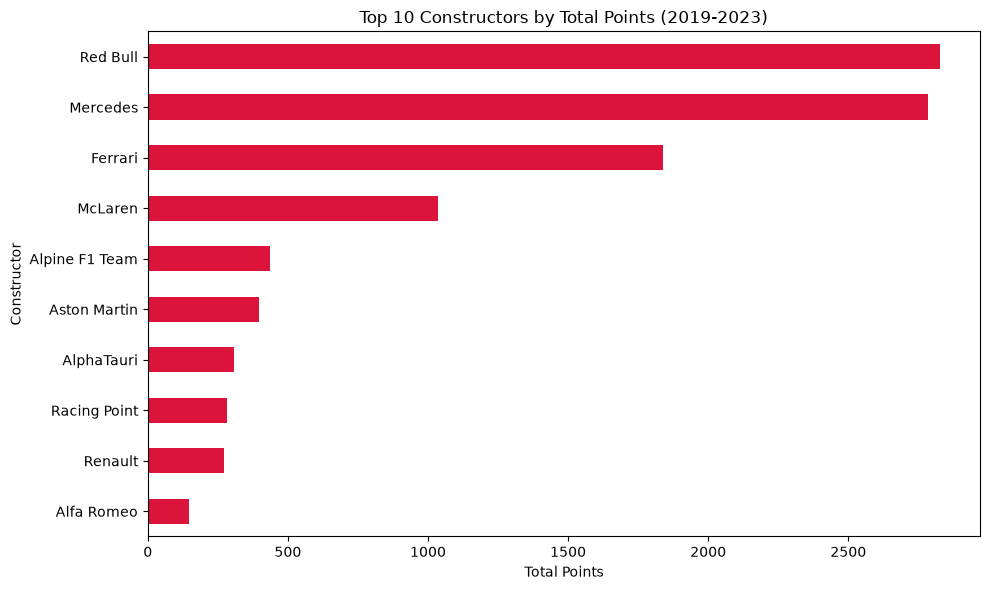

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
constructor_points.head(10).plot(kind='barh', color='crimson')
plt.title('Top 10 Constructors by Total Points (2019-2023)')
plt.xlabel('Total Points')
plt.ylabel('Constructor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
pit_df['driver_id'].unique()[:10]

<StringArray>
[     'gasly',     'norris',    'tsunoda',     'bottas',      'albon',
   'de_vries', 'hulkenberg',   'hamilton',       'ocon',   'sargeant']
Length: 10, dtype: str

In [21]:
avg_pit_time = pit_df.groupby('driver_id')['duration_seconds'].agg(['mean', 'count']).sort_values('mean')
avg_pit_time.columns = ['avg_duration_sec', 'total_stops']
avg_pit_time.head(15)

,avg_duration_sec,total_stops
driver_id,,
leclerc,59.255706,34
kevin_magnussen,101.863395,43
de_vries,115.816889,18
albon,118.909128,39
sargeant,121.223133,45
zhou,143.612481,52
russell,154.148174,46
gasly,178.416977,44
lawson,184.869067,15


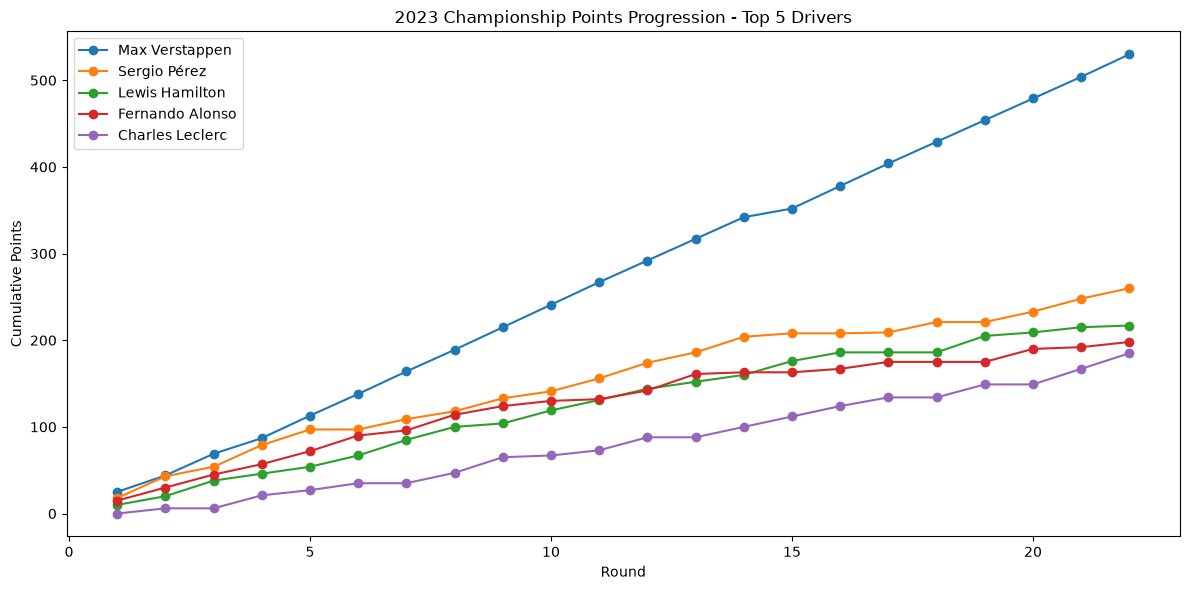

In [22]:
season_2023 = results_df[results_df['season'] == 2023].copy()
season_2023['cumulative_points'] = season_2023.sort_values('round').groupby('driver')['points'].cumsum()

top_5_drivers_2023 = season_2023.groupby('driver')['points'].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12, 6))
for driver in top_5_drivers_2023:
    driver_data = season_2023[season_2023['driver'] == driver].sort_values('round')
    plt.plot(driver_data['round'], driver_data['cumulative_points'], marker='o', label=driver)

plt.title('2023 Championship Points Progression - Top 5 Drivers')
plt.xlabel('Round')
plt.ylabel('Cumulative Points')
plt.legend()
plt.tight_layout()
plt.show()